Found 999 images in test split.
Randomly selected images:
  - data/caltech101/caltech-101/caltech_split/test/ketch/image_0091.jpg
  - data/caltech101/caltech-101/caltech_split/test/Motorbikes/image_0257.jpg
  - data/caltech101/caltech-101/caltech_split/test/llama/image_0053.jpg
  - data/caltech101/caltech-101/caltech_split/test/flamingo/image_0007.jpg

Processing sample #0: data/caltech101/caltech-101/caltech_split/test/ketch/image_0091.jpg
PSNR (SR):  22.4765
SSIM (SR):  0.5619
MSE  (COL): 0.029837


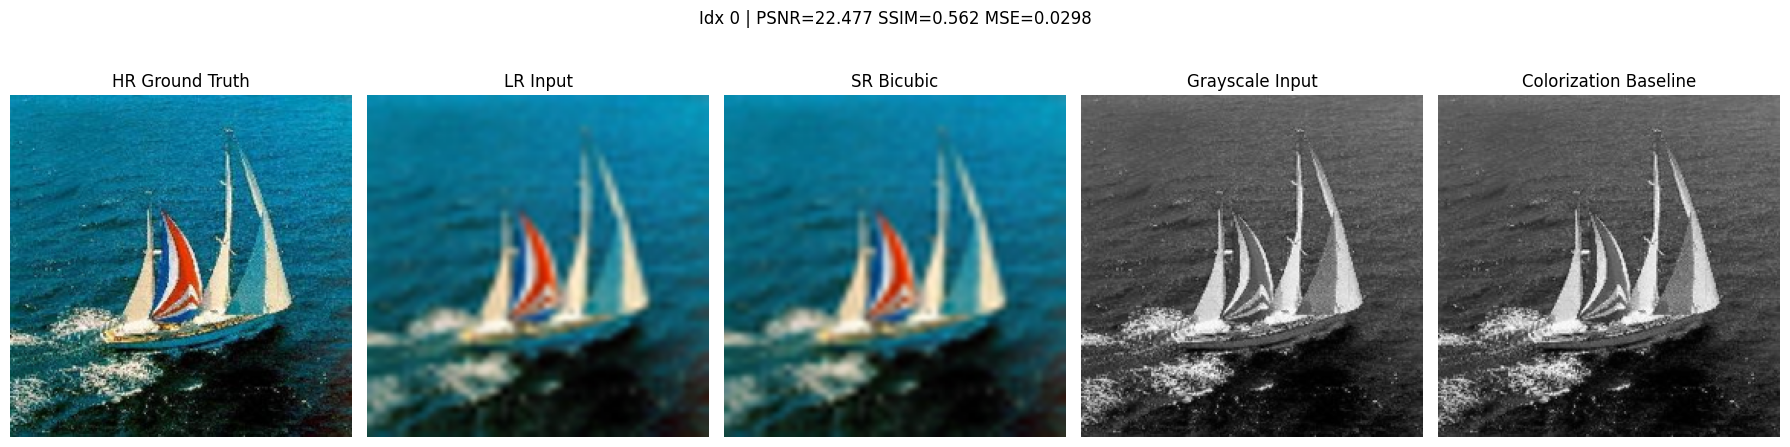


Processing sample #1: data/caltech101/caltech-101/caltech_split/test/Motorbikes/image_0257.jpg
PSNR (SR):  21.6489
SSIM (SR):  0.6709
MSE  (COL): 0.003288


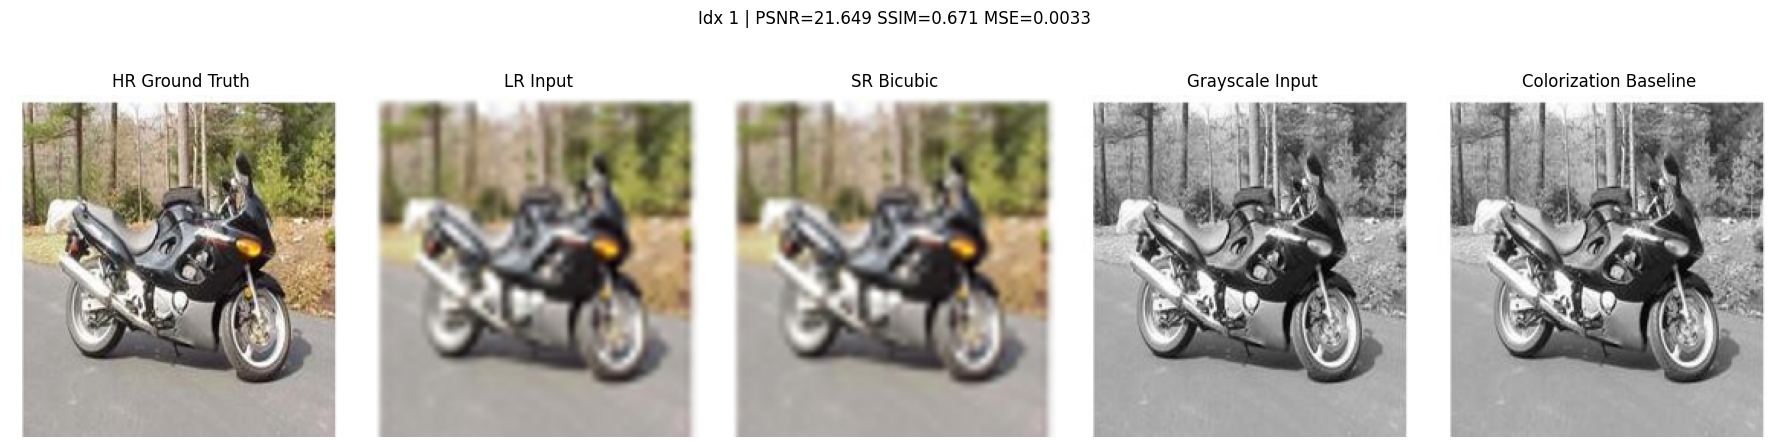


Processing sample #2: data/caltech101/caltech-101/caltech_split/test/llama/image_0053.jpg
PSNR (SR):  22.2607
SSIM (SR):  0.5105
MSE  (COL): 0.004688


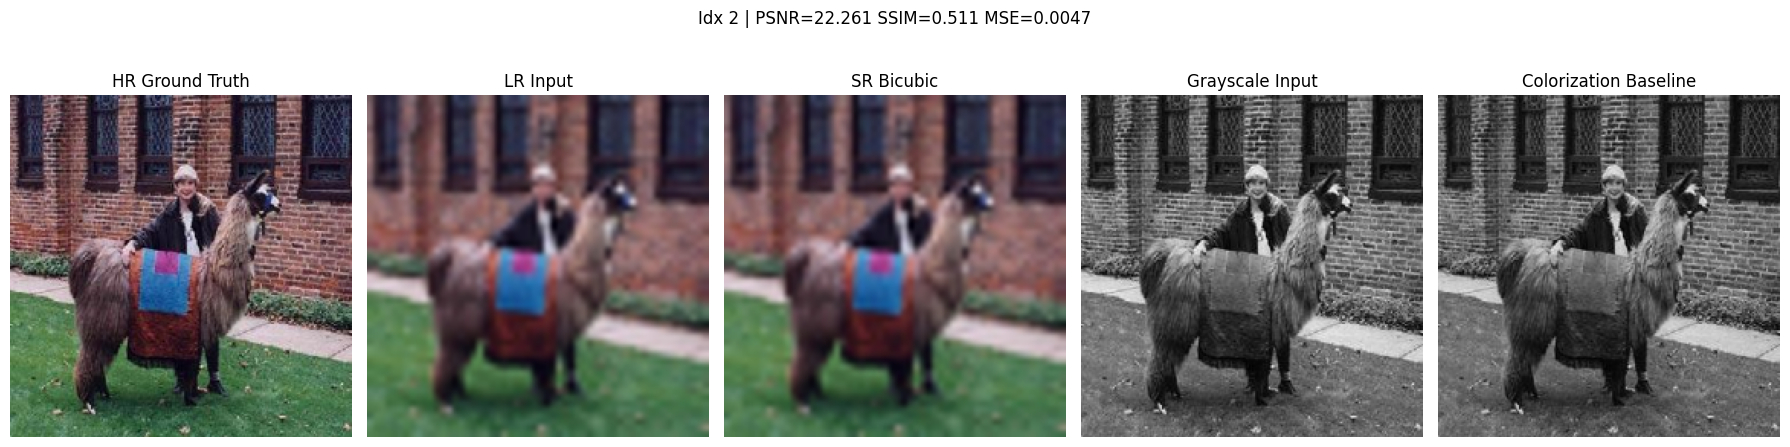


Processing sample #3: data/caltech101/caltech-101/caltech_split/test/flamingo/image_0007.jpg
PSNR (SR):  26.3950
SSIM (SR):  0.9352
MSE  (COL): 0.004285


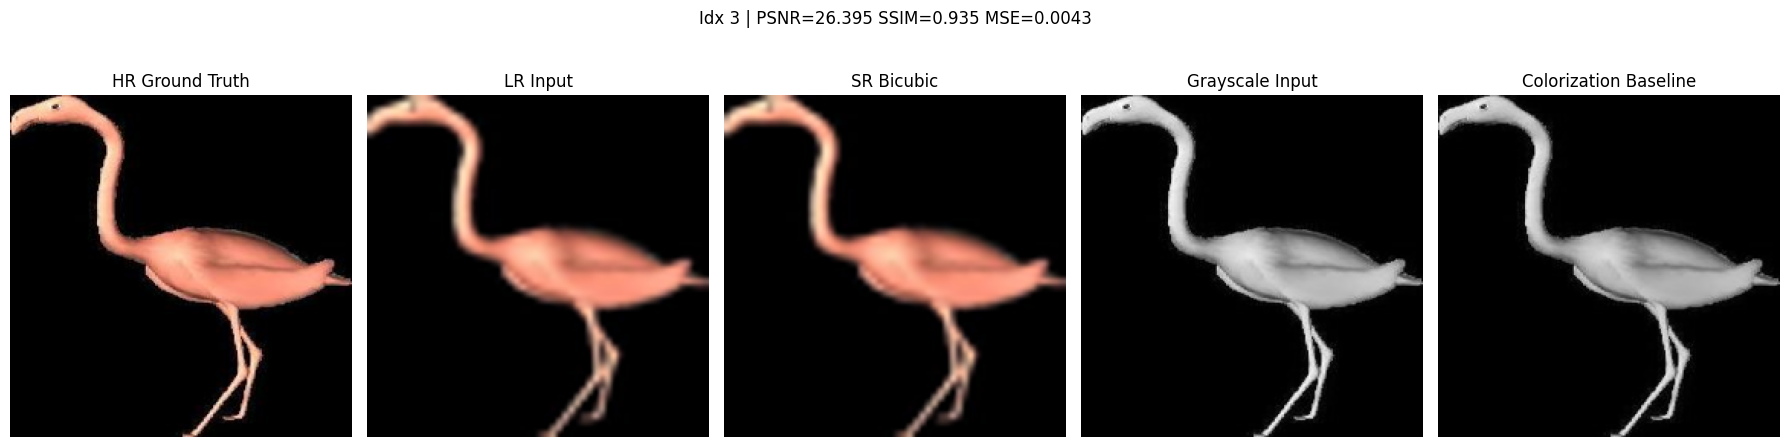

In [8]:
import os
import random
import numpy as np
import torch
import torchvision.transforms as T
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from PIL import Image

# ---------------------------
# CONFIG
# ---------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SCALE = 4
RANDOM_SAMPLES = 4
CALTECH_TEST_DIR = "data/caltech101/caltech-101/caltech_split/test"   # <-- YOUR test split path


# ----------------------------------------------------------
# 1. LOAD IMAGES FROM CLASS-FOLDER STYLE DATASET
# ----------------------------------------------------------

def list_all_images(root):
    """
    Recursively collects all image file paths from folder-style dataset.
    """
    img_files = []
    for rootdir, _, files in os.walk(root):
        for f in files:
            if f.lower().endswith((".jpg", ".jpeg", ".png")):
                img_files.append(os.path.join(rootdir, f))
    return sorted(img_files)


all_images = list_all_images(CALTECH_TEST_DIR)
if len(all_images) == 0:
    raise RuntimeError("No images found in test split folder—check path.")


# ----------------------------------------------------------
# 2. BASELINE FUNCTIONS
# ----------------------------------------------------------

def sr_baseline_bicubic(lr_img_pil):
    """
    LR PIL Image -> SR PIL Image using bicubic resize to 224x224.
    """
    return lr_img_pil.resize((224, 224), Image.BICUBIC)


def colorization_gray_repeat(gray_tensor):
    """
    (1,224,224) grayscale -> repeat to RGB (3,224,224)
    """
    return gray_tensor.repeat(3, 1, 1)


# ----------------------------------------------------------
# 3. METRICS
# ----------------------------------------------------------

def compute_psnr(pred, gt):
    return peak_signal_noise_ratio(gt, pred, data_range=1.0)

def compute_ssim(pred, gt):
    return structural_similarity(gt, pred, channel_axis=2, data_range=1.0)

def compute_mse(pred, gt):
    return ((pred - gt)**2).mean()


# ----------------------------------------------------------
# 4. VISUALIZATION + PROCESSING
# ----------------------------------------------------------

def process_and_visualize(path, idx):
    print(f"\nProcessing sample #{idx}: {path}")

    img = Image.open(path).convert("RGB")

    # HR 224x224
    hr = img.resize((224,224), Image.BICUBIC)

    # LR = downscale ×4 → upscale back
    lr_small = hr.resize((224//SCALE, 224//SCALE), Image.BICUBIC)
    lr = lr_small.resize((224,224), Image.BICUBIC)

    # grayscale
    gray = hr.convert("L")

    # Convert to tensors
    to_tensor = T.ToTensor()
    hr_t   = to_tensor(hr)
    lr_t   = to_tensor(lr)
    gray_t = to_tensor(gray)

    # Baseline SR
    sr_pred = sr_baseline_bicubic(lr)
    sr_t = to_tensor(sr_pred)

    # Baseline Colorization
    col_pred_t = colorization_gray_repeat(gray_t)

    # Convert to numpy
    hr_np = hr_t.permute(1,2,0).numpy()
    lr_np = lr_t.permute(1,2,0).numpy()
    gray_np = gray_t.permute(1,2,0).numpy()
    sr_np = sr_t.permute(1,2,0).numpy()
    col_np = col_pred_t.permute(1,2,0).numpy()

    # Metrics
    psnr = compute_psnr(sr_np, hr_np)
    ssim = compute_ssim(sr_np, hr_np)
    mse  = compute_mse(col_np, hr_np)

    print(f"PSNR (SR):  {psnr:.4f}")
    print(f"SSIM (SR):  {ssim:.4f}")
    print(f"MSE  (COL): {mse:.6f}")

    # Plotting
    fig, ax = plt.subplots(1,5, figsize=(18,5))
    fig.suptitle(f"Idx {idx} | PSNR={psnr:.3f} SSIM={ssim:.3f} MSE={mse:.4f}")

    ax[0].imshow(hr_np); ax[0].set_title("HR Ground Truth"); ax[0].axis("off")
    ax[1].imshow(lr_np); ax[1].set_title("LR Input"); ax[1].axis("off")
    ax[2].imshow(sr_np); ax[2].set_title("SR Bicubic"); ax[2].axis("off")
    ax[3].imshow(gray_np, cmap="gray"); ax[3].set_title("Grayscale Input"); ax[3].axis("off")
    ax[4].imshow(col_np); ax[4].set_title("Colorization Baseline"); ax[4].axis("off")

    plt.tight_layout()
    plt.show()


# ----------------------------------------------------------
# 5. MAIN — RANDOM 4 SAMPLES
# ----------------------------------------------------------

def main():
    print(f"Found {len(all_images)} images in test split.")
    
    chosen = random.sample(all_images, 4)
    print("Randomly selected images:")
    for c in chosen:
        print("  -", c)

    for i, path in enumerate(chosen):
        process_and_visualize(path, i)


if __name__ == "__main__":
    main()
